<a href="https://colab.research.google.com/github/ashiduDissanayake/-Traveller-/blob/main/Canny_Edge_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Canny Edge Detection Implementation


## Import Libraries

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

## Load the Colour Image

Saving images.jpeg to images.jpeg


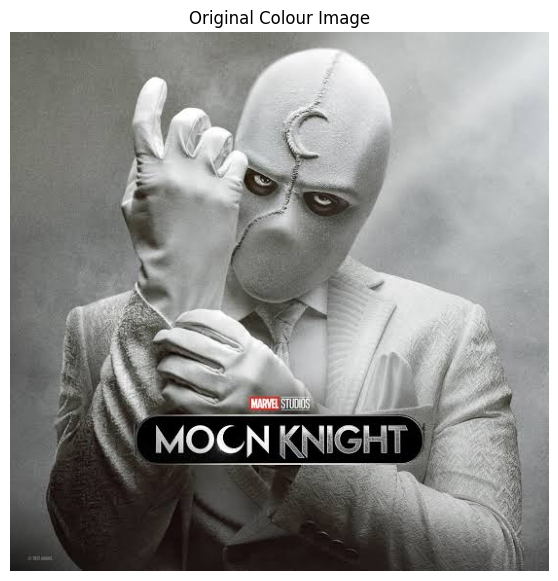

In [ ]:
uploaded = files.upload()
image_name = next(iter(uploaded))
colour_image = cv2.imread(image_name)

if colour_image is None:
    raise ValueError("The selected image could not be loaded.")

plt.figure(figsize=(7, 7))
plt.imshow(colour_image[:, :, ::-1])
plt.title("Original Colour Image")
plt.axis("off")
plt.show()

## Convert the Colour Image to Grayscale

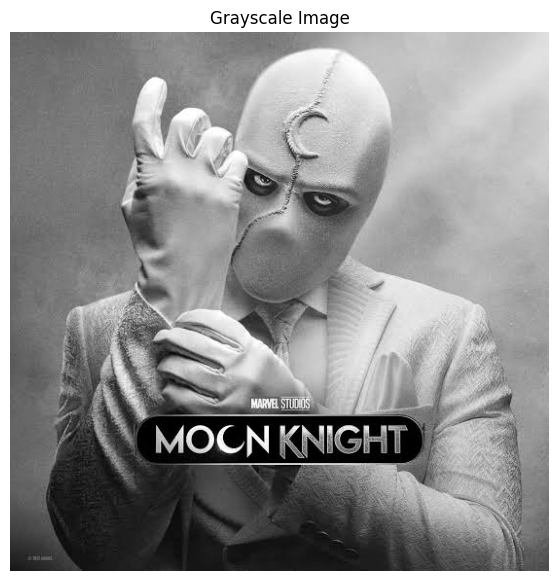

In [ ]:
def convert_to_grayscale(image):
    blue = image[:, :, 0].astype(np.float64)
    green = image[:, :, 1].astype(np.float64)
    red = image[:, :, 2].astype(np.float64)
    grayscale = 0.114 * blue + 0.587 * green + 0.299 * red
    return grayscale

grayscale_image = convert_to_grayscale(colour_image)

plt.figure(figsize=(7, 7))
plt.imshow(grayscale_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

## Two-Dimensional Convolution

In [ ]:
def convolution_2d(image, kernel):
    kernel_height, kernel_width = kernel.shape
    pad_height = kernel_height // 2
    pad_width = kernel_width // 2
    padded_image = np.pad(
        image,
        ((pad_height, pad_height), (pad_width, pad_width)),
        mode="edge"
    )
    output = np.zeros_like(image, dtype=np.float64)

    for row in range(image.shape[0]):
        for column in range(image.shape[1]):
            region = padded_image[
                row:row + kernel_height,
                column:column + kernel_width
            ]
            output[row, column] = np.sum(region * kernel)

    return output

## Stage 1: Gaussian Smoothing

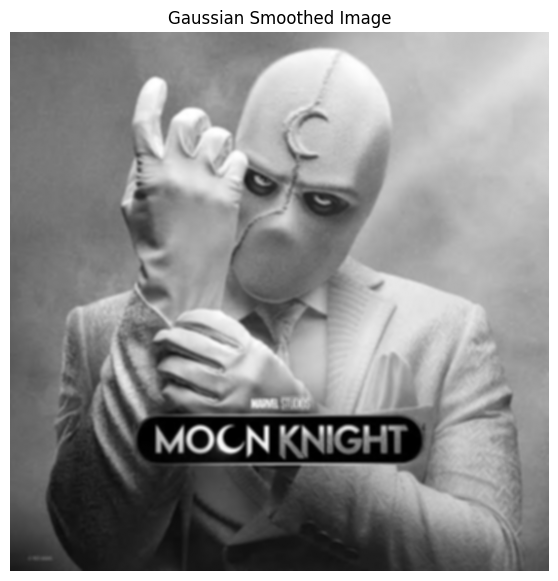

In [ ]:
def create_gaussian_kernel(size, sigma):
    distance = size // 2
    coordinates = np.arange(-distance, distance + 1, dtype=np.float64)
    x, y = np.meshgrid(coordinates, coordinates)
    kernel = np.exp(-(x ** 2 + y ** 2) / (2 * sigma ** 2))
    kernel = kernel / np.sum(kernel)
    return kernel

gaussian_kernel = create_gaussian_kernel(5, 1.4)
smoothed_image = convolution_2d(grayscale_image, gaussian_kernel)

plt.figure(figsize=(7, 7))
plt.imshow(smoothed_image, cmap="gray")
plt.title("Gaussian Smoothed Image")
plt.axis("off")
plt.show()

## Stage 2: Gradient Magnitude and Orientation

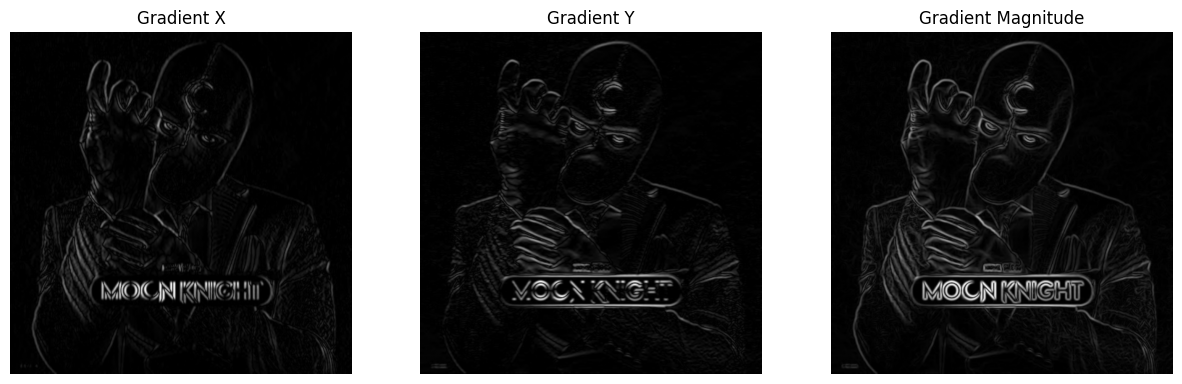

In [ ]:
def calculate_gradients(image):
    sobel_x = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=np.float64)

    sobel_y = np.array([
        [-1, -2, -1],
        [0, 0, 0],
        [1, 2, 1]
    ], dtype=np.float64)

    gradient_x = convolution_2d(image, sobel_x)
    gradient_y = convolution_2d(image, sobel_y)
    magnitude = np.sqrt(gradient_x ** 2 + gradient_y ** 2)
    orientation = np.degrees(np.arctan2(gradient_y, gradient_x))
    orientation = (orientation + 180) % 180

    return gradient_x, gradient_y, magnitude, orientation

gradient_x, gradient_y, gradient_magnitude, gradient_orientation = calculate_gradients(smoothed_image)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(np.abs(gradient_x), cmap="gray")
plt.title("Gradient X")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.abs(gradient_y), cmap="gray")
plt.title("Gradient Y")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gradient_magnitude, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")
plt.show()

## Stage 3: Non-Maximum Suppression

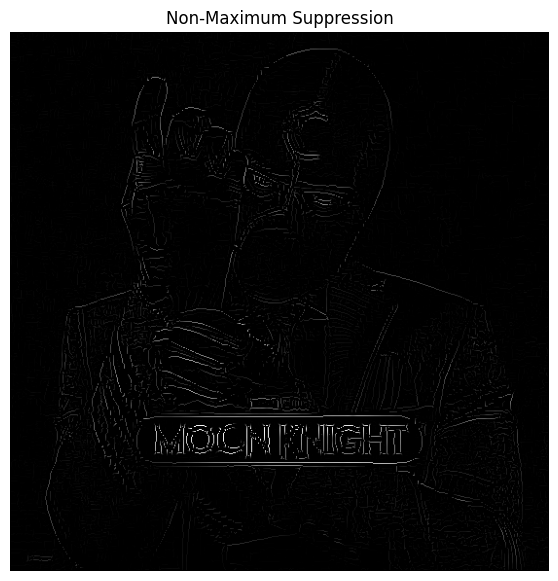

In [ ]:
def non_maximum_suppression(magnitude, orientation):
    height, width = magnitude.shape
    suppressed = np.zeros((height, width), dtype=np.float64)

    for row in range(1, height - 1):
        for column in range(1, width - 1):
            angle = orientation[row, column]

            if angle < 22.5 or angle >= 157.5:
                neighbour_one = magnitude[row, column - 1]
                neighbour_two = magnitude[row, column + 1]
            elif angle < 67.5:
                neighbour_one = magnitude[row - 1, column + 1]
                neighbour_two = magnitude[row + 1, column - 1]
            elif angle < 112.5:
                neighbour_one = magnitude[row - 1, column]
                neighbour_two = magnitude[row + 1, column]
            else:
                neighbour_one = magnitude[row - 1, column - 1]
                neighbour_two = magnitude[row + 1, column + 1]

            current_pixel = magnitude[row, column]

            if current_pixel >= neighbour_one and current_pixel >= neighbour_two:
                suppressed[row, column] = current_pixel

    return suppressed

suppressed_image = non_maximum_suppression(gradient_magnitude, gradient_orientation)

plt.figure(figsize=(7, 7))
plt.imshow(suppressed_image, cmap="gray")
plt.title("Non-Maximum Suppression")
plt.axis("off")
plt.show()

## Stage 4: Double Thresholding

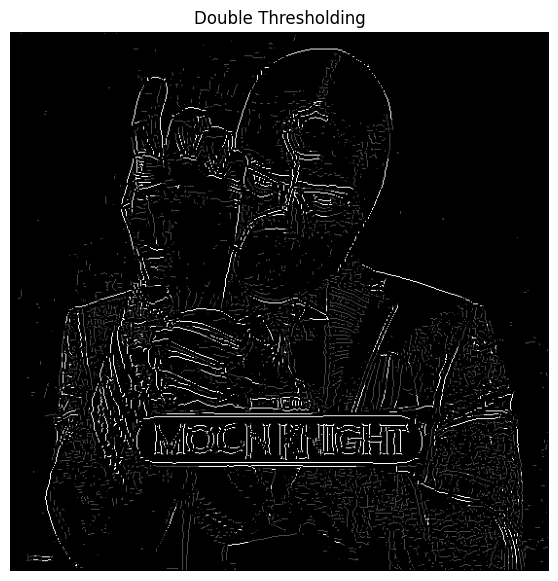

In [ ]:
def double_threshold(image, low_threshold, high_threshold):
    strong_value = 255
    weak_value = 75
    thresholded = np.zeros(image.shape, dtype=np.uint8)

    strong_rows, strong_columns = np.where(image >= high_threshold)
    weak_rows, weak_columns = np.where(
        (image >= low_threshold) & (image < high_threshold)
    )

    thresholded[strong_rows, strong_columns] = strong_value
    thresholded[weak_rows, weak_columns] = weak_value

    return thresholded, weak_value, strong_value

low_threshold = 20
high_threshold = 80
thresholded_image, weak_value, strong_value = double_threshold(
    suppressed_image,
    low_threshold,
    high_threshold
)

plt.figure(figsize=(7, 7))
plt.imshow(thresholded_image, cmap="gray", vmin=0, vmax=255)
plt.title("Double Thresholding")
plt.axis("off")
plt.show()

## Stage 5: Edge Tracking by Hysteresis

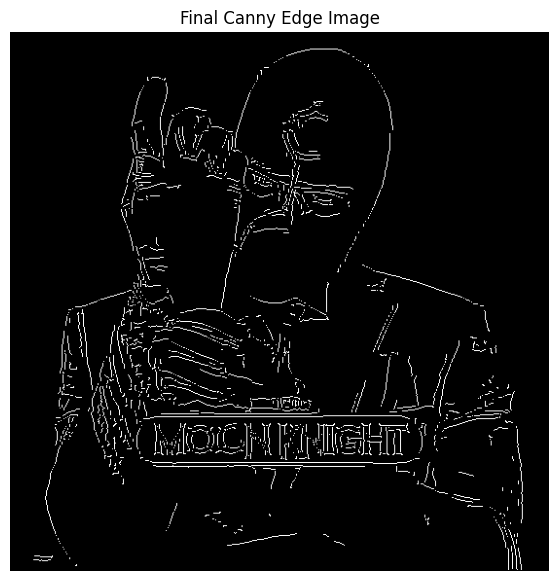

In [ ]:
def edge_tracking_by_hysteresis(image, weak_value, strong_value):
    final_edges = image.copy()
    height, width = final_edges.shape
    strong_locations = list(zip(*np.where(final_edges == strong_value)))

    while strong_locations:
        row, column = strong_locations.pop()

        for row_offset in (-1, 0, 1):
            for column_offset in (-1, 0, 1):
                neighbour_row = row + row_offset
                neighbour_column = column + column_offset

                inside_image = (
                    0 <= neighbour_row < height
                    and 0 <= neighbour_column < width
                )

                if inside_image and final_edges[neighbour_row, neighbour_column] == weak_value:
                    final_edges[neighbour_row, neighbour_column] = strong_value
                    strong_locations.append((neighbour_row, neighbour_column))

    final_edges[final_edges != strong_value] = 0
    return final_edges

final_edge_image = edge_tracking_by_hysteresis(
    thresholded_image,
    weak_value,
    strong_value
)

plt.figure(figsize=(7, 7))
plt.imshow(final_edge_image, cmap="gray", vmin=0, vmax=255)
plt.title("Final Canny Edge Image")
plt.axis("off")
plt.show()

## Compare the Main Stages

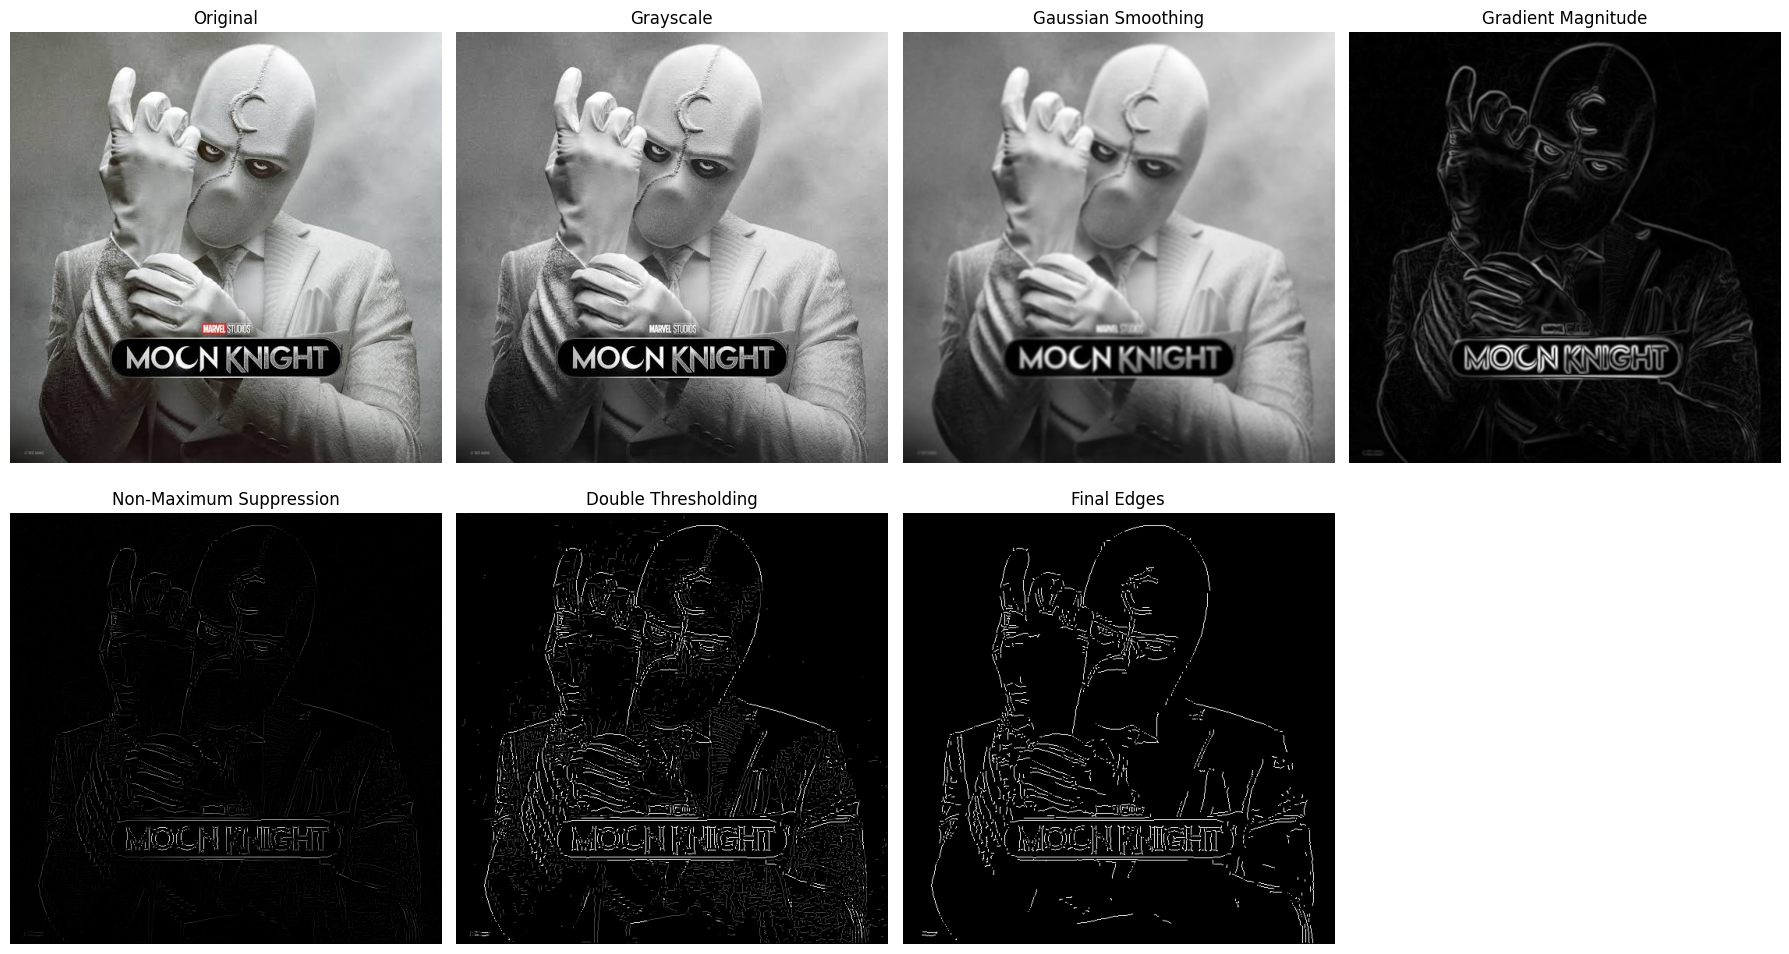

In [ ]:
images = [
    colour_image[:, :, ::-1],
    grayscale_image,
    smoothed_image,
    gradient_magnitude,
    suppressed_image,
    thresholded_image,
    final_edge_image
]

titles = [
    "Original",
    "Grayscale",
    "Gaussian Smoothing",
    "Gradient Magnitude",
    "Non-Maximum Suppression",
    "Double Thresholding",
    "Final Edges"
]

plt.figure(figsize=(18, 10))

for index, image in enumerate(images):
    plt.subplot(2, 4, index + 1)
    if index == 0:
        plt.imshow(image)
    else:
        plt.imshow(image, cmap="gray")
    plt.title(titles[index])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Save the Results

In [ ]:
cv2.imwrite("grayscale_image.png", np.clip(grayscale_image, 0, 255).astype(np.uint8))
cv2.imwrite("smoothed_image.png", np.clip(smoothed_image, 0, 255).astype(np.uint8))
cv2.imwrite("gradient_magnitude.png", np.clip(gradient_magnitude, 0, 255).astype(np.uint8))
cv2.imwrite("non_maximum_suppression.png", np.clip(suppressed_image, 0, 255).astype(np.uint8))
cv2.imwrite("double_thresholding.png", thresholded_image)
cv2.imwrite("final_canny_edges.png", final_edge_image)

files.download("final_canny_edges.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>